In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / "src" / "mlops_end_2_end").is_dir() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import mlops_end_2_end.model.model_explainer as model_explainer_module
importlib.reload(model_explainer_module)
LightGBMSHAPExplainer = model_explainer_module.LightGBMSHAPExplainer

In [2]:
import pickle

model_path = project_root / "models" / "trained" / "lightgbm_model.pkl"
with model_path.open("rb") as model_file:
    model = pickle.load(model_file)

explainer = LightGBMSHAPExplainer(model=model, project_root=project_root)

In [3]:
import mlops_end_2_end.model.model_training as model_training_module

df = pd.read_csv(project_root / "data" / "engineered_features" / "engineered_features.csv")
trainer = model_training_module.LightGBMModelTraining(project_root=project_root)
_, validation_df = trainer.split_data(df)
X_val, y = trainer.prepare_features(validation_df)

2026-10-04 22:01:31 - model_training - INFO - Training samples: 292
2026-10-04 22:01:31 - model_training - INFO - Validation samples: 73


In [4]:
importance = explainer.feature_importance(X_val)

print(importance)


2026-10-04 22:01:36 - model_explainability - INFO - Calculating SHAP values for 73 samples


                  feature  importance
0            sales_lag_28   12.436030
1             sales_lag_7    7.280868
2               promotion    6.456941
3             day_of_week    5.390198
4            sales_lag_14    4.874228
5                   trend    3.161038
6                   price    2.067600
7            week_of_year    1.084355
8             sales_lag_1    0.747410
9   sales_rolling_mean_28    0.722814
10   sales_rolling_std_28    0.673582
11  sales_rolling_mean_14    0.555779
12    sales_rolling_std_7    0.385287
13                  month    0.349437
14                    day    0.259387
15            temperature    0.232179
16   sales_rolling_std_14    0.211520
17   sales_rolling_mean_7    0.088434
18                holiday    0.000000
19                   year    0.000000


2026-10-04 22:02:12 - model_explainability - INFO - Calculating SHAP values for 73 samples


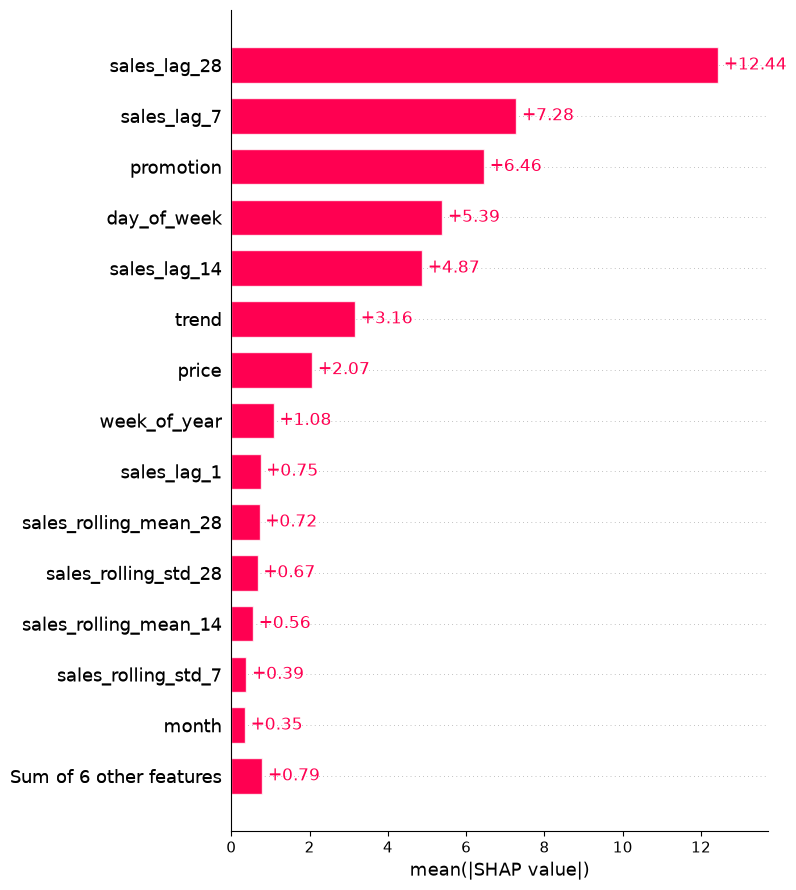

In [5]:
explainer.plot_feature_importance(
    X_val,
    max_display=15,
)


2026-10-04 22:02:21 - model_explainability - INFO - Calculating SHAP values for 73 samples


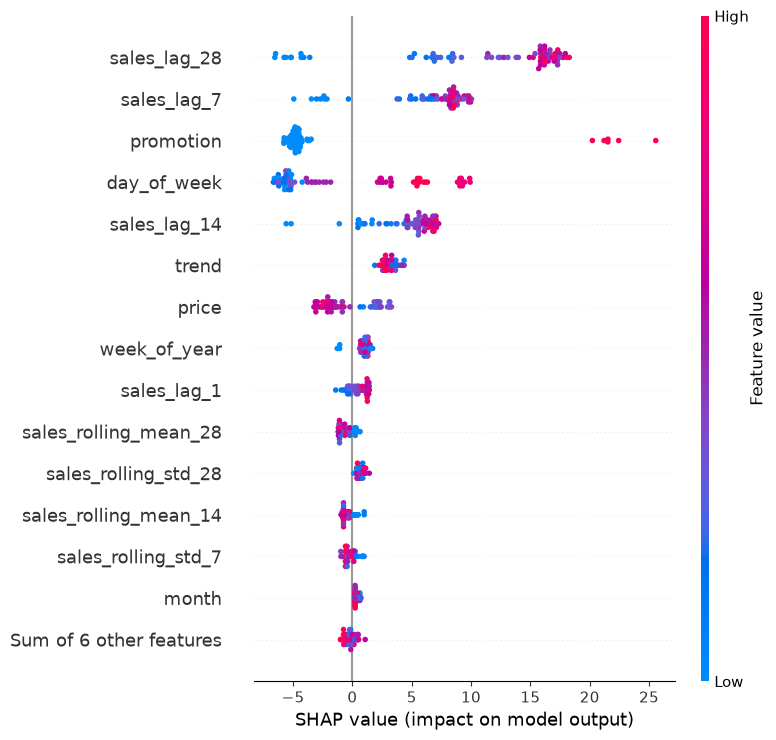

In [6]:
explainer.plot_summary(
    X_val,
    max_display=15,
)